In [3]:
from google.colab import files

uploaded = files.upload()

Saving india_2000_2024_daily_weather.csv to india_2000_2024_daily_weather.csv


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("india_2000_2024_daily_weather.csv")

In [6]:
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322


In [7]:
df.shape

(91320, 12)

In [8]:
df.columns

Index(['city', 'date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   city                         91320 non-null  object 
 1   date                         91320 non-null  object 
 2   temperature_2m_max           91320 non-null  float64
 3   temperature_2m_min           91320 non-null  float64
 4   apparent_temperature_max     91320 non-null  float64
 5   apparent_temperature_min     91320 non-null  float64
 6   precipitation_sum            91320 non-null  float64
 7   rain_sum                     91320 non-null  float64
 8   weather_code                 91320 non-null  int64  
 9   wind_speed_10m_max           91320 non-null  float64
 10  wind_gusts_10m_max           91320 non-null  float64
 11  wind_direction_10m_dominant  91320 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 8.4+ MB


In [10]:
df["date"] = pd.to_datetime(df["date"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   city                         91320 non-null  object        
 1   date                         91320 non-null  datetime64[ns]
 2   temperature_2m_max           91320 non-null  float64       
 3   temperature_2m_min           91320 non-null  float64       
 4   apparent_temperature_max     91320 non-null  float64       
 5   apparent_temperature_min     91320 non-null  float64       
 6   precipitation_sum            91320 non-null  float64       
 7   rain_sum                     91320 non-null  float64       
 8   weather_code                 91320 non-null  int64         
 9   wind_speed_10m_max           91320 non-null  float64       
 10  wind_gusts_10m_max           91320 non-null  float64       
 11  wind_direction_10m_dominant  91320 non-nu

In [12]:
df["city"].unique()

array(['Delhi', 'Mumbai', 'Kolkata', 'Chennai', 'Bangalore', 'Hyderabad',
       'Ahmedabad', 'Pune', 'Jaipur', 'Lucknow'], dtype=object)

In [13]:
df["city"].value_counts()

,count
city,
Delhi,9132
Mumbai,9132
Kolkata,9132
Chennai,9132
Bangalore,9132
Hyderabad,9132
Ahmedabad,9132
Pune,9132
Jaipur,9132


In [14]:
print(df["date"].max())
print(df["date"].min())

2024-12-31 00:00:00
2000-01-01 00:00:00


In [15]:
print(df.groupby("city")["date"].agg(["min", "max"]))

                 min        max
city                           
Ahmedabad 2000-01-01 2024-12-31
Bangalore 2000-01-01 2024-12-31
Chennai   2000-01-01 2024-12-31
Delhi     2000-01-01 2024-12-31
Hyderabad 2000-01-01 2024-12-31
Jaipur    2000-01-01 2024-12-31
Kolkata   2000-01-01 2024-12-31
Lucknow   2000-01-01 2024-12-31
Mumbai    2000-01-01 2024-12-31
Pune      2000-01-01 2024-12-31


In [16]:
print(df.duplicated().sum())

0


In [17]:
print(df["date"].min())
print(df["date"].max())

print(df.groupby("city")["date"].agg(["min", "max"]))

print(df.duplicated().sum())

2000-01-01 00:00:00
2024-12-31 00:00:00
                 min        max
city                           
Ahmedabad 2000-01-01 2024-12-31
Bangalore 2000-01-01 2024-12-31
Chennai   2000-01-01 2024-12-31
Delhi     2000-01-01 2024-12-31
Hyderabad 2000-01-01 2024-12-31
Jaipur    2000-01-01 2024-12-31
Kolkata   2000-01-01 2024-12-31
Lucknow   2000-01-01 2024-12-31
Mumbai    2000-01-01 2024-12-31
Pune      2000-01-01 2024-12-31
0


In [18]:
expected_days = pd.date_range(
    start="2000-01-01",
    end="2024-12-31",
    freq="D"
)

print("Expected days:", len(expected_days))

Expected days: 9132


In [19]:
for city in df["city"].unique():

    city_dates = df[df["city"] == city]["date"]

    print(city, len(city_dates), city_dates.nunique())

Delhi 9132 9132
Mumbai 9132 9132
Kolkata 9132 9132
Chennai 9132 9132
Bangalore 9132 9132
Hyderabad 9132 9132
Ahmedabad 9132 9132
Pune 9132 9132
Jaipur 9132 9132
Lucknow 9132 9132


In [20]:
df = df.sort_values(["city", "date"])

In [21]:
df["target_temperature"] = df.groupby("city")["temperature_2m_max"].shift(-1)

In [22]:
df[df["city"] == "Delhi"][
    ["date", "temperature_2m_max", "target_temperature"]
].head(10)

,date,temperature_2m_max,target_temperature
0,2000-01-01,19.9,20.0
1,2000-01-02,20.0,20.1
2,2000-01-03,20.1,19.8
3,2000-01-04,19.8,19.4
4,2000-01-05,19.4,19.2
5,2000-01-06,19.2,19.1
6,2000-01-07,19.1,20.3
7,2000-01-08,20.3,22.0
8,2000-01-09,22.0,19.1
9,2000-01-10,19.1,23.0


In [23]:
df.describe()

,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,target_temperature
count,91320,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91310.000000
mean,2012-07-01 12:00:00,30.900903,21.129450,33.058268,22.863710,3.092751,3.092751,24.494492,15.523795,32.176491,196.760469,30.901510
min,2000-01-01 00:00:00,12.300000,1.700000,10.200000,-1.100000,0.000000,0.000000,0.000000,3.600000,10.400000,0.000000,12.300000
25%,2006-04-01 18:00:00,27.800000,18.000000,29.200000,18.000000,0.000000,0.000000,1.000000,11.500000,25.200000,98.000000,27.800000
50%,2012-07-01 12:00:00,30.700000,22.100000,33.600000,24.000000,0.000000,0.000000,3.000000,14.800000,31.000000,223.000000,30.700000
75%,2018-10-01 06:00:00,33.800000,25.300000,37.600000,29.100000,1.700000,1.700000,53.000000,18.700000,37.800000,283.000000,33.800000
max,2024-12-31 00:00:00,46.400000,34.400000,49.400000,37.800000,339.900000,339.900000,65.000000,68.900000,142.900000,360.000000,46.400000
std,NaN,4.770039,5.291931,5.988028,7.331756,9.164448,9.164448,27.267100,5.205461,9.576481,103.002164,4.769797


In [24]:
df.corr(numeric_only=True)

,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,target_temperature
temperature_2m_max,1.000000,0.700101,0.898065,0.591302,-0.171679,-0.171679,-0.113443,0.176743,0.159742,0.076199,0.964966
temperature_2m_min,0.700101,1.000000,0.870750,0.970569,0.177757,0.177757,0.411934,0.386666,0.372513,0.039722,0.681189
apparent_temperature_max,0.898065,0.870750,1.000000,0.837818,-0.017396,-0.017396,0.165140,0.136111,0.117715,0.027193,0.867388
apparent_temperature_min,0.591302,0.970569,0.837818,1.000000,0.208929,0.208929,0.487210,0.301802,0.296489,0.020474,0.574596
precipitation_sum,-0.171679,0.177757,-0.017396,0.208929,1.000000,1.000000,0.460591,0.182953,0.207712,0.008890,-0.152942
rain_sum,-0.171679,0.177757,-0.017396,0.208929,1.000000,1.000000,0.460591,0.182953,0.207712,0.008890,-0.152942
weather_code,-0.113443,0.411934,0.165140,0.487210,0.460591,0.460591,1.000000,0.215158,0.280982,-0.014757,-0.118956
wind_speed_10m_max,0.176743,0.386666,0.136111,0.301802,0.182953,0.182953,0.215158,1.000000,0.906837,0.148269,0.165920
wind_gusts_10m_max,0.159742,0.372513,0.117715,0.296489,0.207712,0.207712,0.280982,0.906837,1.000000,0.142413,0.148762
wind_direction_10m_dominant,0.076199,0.039722,0.027193,0.020474,0.008890,0.008890,-0.014757,0.148269,0.142413,1.000000,0.078978


In [25]:
df["month"] = df["date"].dt.month

In [26]:
df[["date", "month"]].head(10)

,date,month
54792,2000-01-01,1
54793,2000-01-02,1
54794,2000-01-03,1
54795,2000-01-04,1
54796,2000-01-05,1
54797,2000-01-06,1
54798,2000-01-07,1
54799,2000-01-08,1
54800,2000-01-09,1
54801,2000-01-10,1


In [27]:
df["month"] = df["date"].dt.month

df[["date", "month"]].head(10)

,date,month
54792,2000-01-01,1
54793,2000-01-02,1
54794,2000-01-03,1
54795,2000-01-04,1
54796,2000-01-05,1
54797,2000-01-06,1
54798,2000-01-07,1
54799,2000-01-08,1
54800,2000-01-09,1
54801,2000-01-10,1


In [28]:
df["target_temperature"].isnull().sum()

np.int64(10)

In [29]:
df = df.dropna(subset=["target_temperature"])

In [30]:
df.shape

(91310, 14)

In [31]:
features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "precipitation_sum",
    "weather_code",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
    "month"
]

In [32]:
X = df[features]

y = df["target_temperature"]

In [33]:
print(X.shape)
print(y.shape)

(91310, 10)
(91310,)


In [34]:
train_df = df[df["date"] < "2020-01-01"]
test_df = df[df["date"] >= "2020-01-01"]

In [35]:
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (73050, 14)
Test: (18260, 14)


In [36]:
X_train = train_df[features]
y_train = train_df["target_temperature"]

X_test = test_df[features]
y_test = test_df["target_temperature"]

In [37]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(73050, 10)
(18260, 10)
(73050,)
(18260,)


In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
model = LinearRegression()


In [40]:
model.fit(X_train, y_train)

LinearRegression()

In [41]:
model.fit(X_train, y_train)

LinearRegression()

In [42]:
y_pred = model.predict(X_test)

In [43]:
print(y_pred[:10])

[25.93383694 25.91424083 24.92749111 25.28563582 25.29670078 27.42045314
 27.12932062 25.81436415 23.14224012 23.31597252]


In [44]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(comparison)

   Actual  Predicted
0    25.5  25.933837
1    24.5  25.914241
2    24.9  24.927491
3    25.0  25.285636
4    27.2  25.296701
5    26.7  27.420453
6    25.3  27.129321
7    22.8  25.814364
8    23.0  23.142240
9    26.3  23.315973


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.940062155920351
RMSE: 1.311063622889186
R²  : 0.925567721907662


In [46]:
df["temp_lag_1"] = (
    df.groupby("city")["temperature_2m_max"].shift(1)
)

df["temp_lag_2"] = (
    df.groupby("city")["temperature_2m_max"].shift(2)
)

df["temp_lag_3"] = (
    df.groupby("city")["temperature_2m_max"].shift(3)
)

df["temp_lag_7"] = (
    df.groupby("city")["temperature_2m_max"].shift(7)
)

In [47]:
df[df["city"] == "Delhi"][
    [
        "date",
        "temperature_2m_max",
        "temp_lag_1",
        "temp_lag_2",
        "temp_lag_3",
        "temp_lag_7"
    ]
].head(12)

,date,temperature_2m_max,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_7
0,2000-01-01,19.9,NaN,NaN,NaN,NaN
1,2000-01-02,20.0,19.9,NaN,NaN,NaN
2,2000-01-03,20.1,20.0,19.9,NaN,NaN
3,2000-01-04,19.8,20.1,20.0,19.9,NaN
4,2000-01-05,19.4,19.8,20.1,20.0,NaN
5,2000-01-06,19.2,19.4,19.8,20.1,NaN
6,2000-01-07,19.1,19.2,19.4,19.8,NaN
7,2000-01-08,20.3,19.1,19.2,19.4,19.9
8,2000-01-09,22.0,20.3,19.1,19.2,20.0
9,2000-01-10,19.1,22.0,20.3,19.1,20.1


In [48]:
features_v2 = [
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "precipitation_sum",
    "weather_code",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
    "month",
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_lag_7"
]

In [49]:
df_v2 = df.dropna(subset=[
    "target_temperature",
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_lag_7"
]).copy()

In [50]:
print(df_v2.shape)

(91240, 18)


In [51]:
train_v2 = df_v2[df_v2["date"] < "2020-01-01"]
test_v2 = df_v2[df_v2["date"] >= "2020-01-01"]

In [52]:
X_train_v2 = train_v2[features_v2]
y_train_v2 = train_v2["target_temperature"]

X_test_v2 = test_v2[features_v2]
y_test_v2 = test_v2["target_temperature"]

In [53]:
print(X_train_v2.shape)
print(X_test_v2.shape)

(72980, 14)
(18260, 14)


In [54]:
model_v2 = LinearRegression()

model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)

In [55]:
mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)

rmse_v2 = np.sqrt(
    mean_squared_error(y_test_v2, y_pred_v2)
)

r2_v2 = r2_score(y_test_v2, y_pred_v2)

print("New Model")
print("MAE :", mae_v2)
print("RMSE:", rmse_v2)
print("R²  :", r2_v2)

New Model
MAE : 0.9327170725957119
RMSE: 1.2916779394612186
R²  : 0.9277525936099933


In [56]:
df["temp_rolling_3"] = (
    df.groupby("city")["temperature_2m_max"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["temp_rolling_7"] = (
    df.groupby("city")["temperature_2m_max"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

In [57]:
df[df["city"] == "Delhi"][
    [
        "date",
        "temperature_2m_max",
        "temp_rolling_3",
        "temp_rolling_7"
    ]
].head(12)

,date,temperature_2m_max,temp_rolling_3,temp_rolling_7
0,2000-01-01,19.9,NaN,NaN
1,2000-01-02,20.0,NaN,NaN
2,2000-01-03,20.1,NaN,NaN
3,2000-01-04,19.8,20.000000,NaN
4,2000-01-05,19.4,19.966667,NaN
5,2000-01-06,19.2,19.766667,NaN
6,2000-01-07,19.1,19.466667,NaN
7,2000-01-08,20.3,19.233333,19.642857
8,2000-01-09,22.0,19.533333,19.700000
9,2000-01-10,19.1,20.466667,19.985714


In [58]:
features_v3 = [
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "precipitation_sum",
    "weather_code",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
    "month",
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_lag_7",
    "temp_rolling_3",
    "temp_rolling_7"
]

In [59]:
df_v3 = df.dropna(
    subset=[
        "target_temperature",
        "temp_lag_1",
        "temp_lag_2",
        "temp_lag_3",
        "temp_lag_7",
        "temp_rolling_3",
        "temp_rolling_7"
    ]
).copy()

In [60]:
print(df_v3.shape)

(91240, 20)


In [61]:
train_v3 = df_v3[df_v3["date"] < "2020-01-01"]
test_v3 = df_v3[df_v3["date"] >= "2020-01-01"]

In [62]:
X_train_v3 = train_v3[features_v3]
y_train_v3 = train_v3["target_temperature"]

X_test_v3 = test_v3[features_v3]
y_test_v3 = test_v3["target_temperature"]

In [63]:
model_v3 = LinearRegression()

model_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = model_v3.predict(X_test_v3)

In [64]:
mae_v3 = mean_absolute_error(y_test_v3, y_pred_v3)

rmse_v3 = np.sqrt(
    mean_squared_error(y_test_v3, y_pred_v3)
)

r2_v3 = r2_score(y_test_v3, y_pred_v3)

print("Model 3")
print("MAE :", mae_v3)
print("RMSE:", rmse_v3)
print("R²  :", r2_v3)

Model 3
MAE : 0.9316765034998229
RMSE: 1.2900754141837265
R²  : 0.9279317504586806


In [65]:
from sklearn.ensemble import RandomForestRegressor

In [66]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [67]:
rf_model.fit(X_train_v3, y_train_v3)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [68]:
y_pred_rf = rf_model.predict(X_test_v3)

In [69]:
mae_rf = mean_absolute_error(y_test_v3, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test_v3, y_pred_rf)
)

r2_rf = r2_score(y_test_v3, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 0.9237191128148959
RMSE: 1.2763050206554363
R²  : 0.9294620666160845


In [70]:
importance = pd.DataFrame({
    "Feature": features_v3,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                        Feature  Importance
0            temperature_2m_max    0.934545
15               temp_rolling_7    0.005966
8   wind_direction_10m_dominant    0.005717
13                   temp_lag_7    0.005617
10                   temp_lag_1    0.005166
4             precipitation_sum    0.004985
3      apparent_temperature_min    0.004945
2      apparent_temperature_max    0.004559
6            wind_speed_10m_max    0.004510
1            temperature_2m_min    0.004273
12                   temp_lag_3    0.004244
7            wind_gusts_10m_max    0.004147
11                   temp_lag_2    0.003847
14               temp_rolling_3    0.003430
9                         month    0.002331
5                  weather_code    0.001718


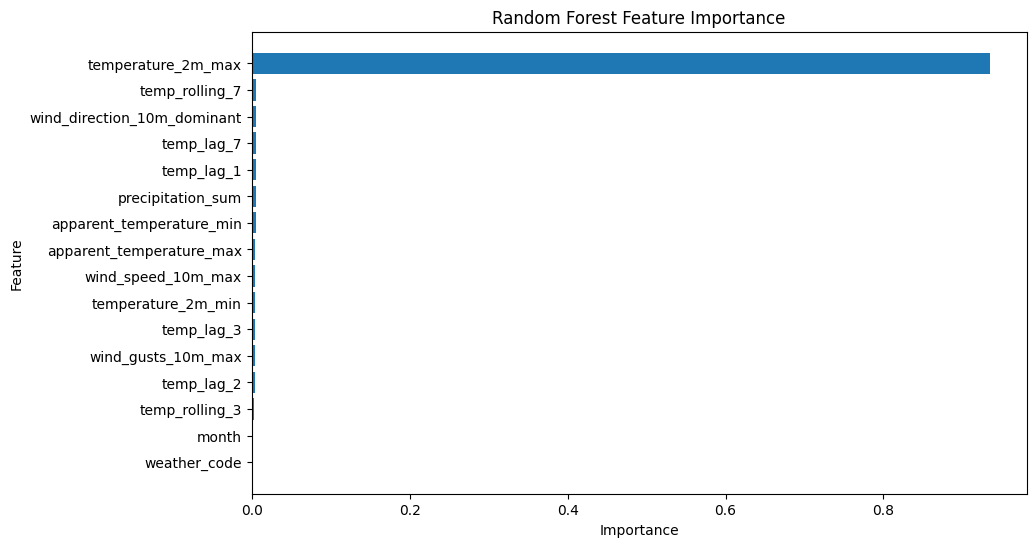

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [72]:
features_no_today_max = [
    "temperature_2m_min",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "precipitation_sum",
    "weather_code",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
    "month",
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_lag_7",
    "temp_rolling_3",
    "temp_rolling_7"
]

In [73]:
rf_no_today_max = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_no_today_max.fit(
    train_v3[features_no_today_max],
    y_train_v3
)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [74]:
y_pred_no_today_max = rf_no_today_max.predict(
    test_v3[features_no_today_max]
)

In [75]:
mae_no_today_max = mean_absolute_error(
    y_test_v3,
    y_pred_no_today_max
)

rmse_no_today_max = np.sqrt(
    mean_squared_error(
        y_test_v3,
        y_pred_no_today_max
    )
)

r2_no_today_max = r2_score(
    y_test_v3,
    y_pred_no_today_max
)

print("Random Forest WITHOUT today's max temperature")
print("MAE :", mae_no_today_max)
print("RMSE:", rmse_no_today_max)
print("R²  :", r2_no_today_max)

Random Forest WITHOUT today's max temperature
MAE : 1.0378580503833517
RMSE: 1.4035012296549423
R²  : 0.9147018972901989


In [76]:
rf_200 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_200.fit(X_train_v3, y_train_v3)

y_pred_200 = rf_200.predict(X_test_v3)

In [77]:
mae_200 = mean_absolute_error(y_test_v3, y_pred_200)

rmse_200 = np.sqrt(
    mean_squared_error(y_test_v3, y_pred_200)
)

r2_200 = r2_score(y_test_v3, y_pred_200)

print("Random Forest - 200 Trees")
print("MAE :", mae_200)
print("RMSE:", rmse_200)
print("R²  :", r2_200)

Random Forest - 200 Trees
MAE : 0.9205945783132531
RMSE: 1.2724764643403468
R²  : 0.9298846198400008


In [78]:
final_comparison = pd.DataFrame({
    "Actual": y_test_v3.values,
    "Predicted": y_pred_200
})

final_comparison["Error"] = (
    final_comparison["Actual"] -
    final_comparison["Predicted"]
)

print(final_comparison.head(20))

    Actual  Predicted   Error
0     25.5    26.0145 -0.5145
1     24.5    25.7755 -1.2755
2     24.9    24.3210  0.5790
3     25.0    24.9705  0.0295
4     27.2    25.2550  1.9450
5     26.7    26.9050 -0.2050
6     25.3    26.3240 -1.0240
7     22.8    24.7410 -1.9410
8     23.0    22.4270  0.5730
9     26.3    23.7700  2.5300
10    29.2    26.2870  2.9130
11    24.6    28.6570 -4.0570
12    23.8    24.4195 -0.6195
13    23.5    23.8805 -0.3805
14    22.0    23.7115 -1.7115
15    23.3    21.9120  1.3880
16    24.5    23.6865  0.8135
17    25.3    24.8280  0.4720
18    25.8    25.3520  0.4480
19    26.9    26.1085  0.7915


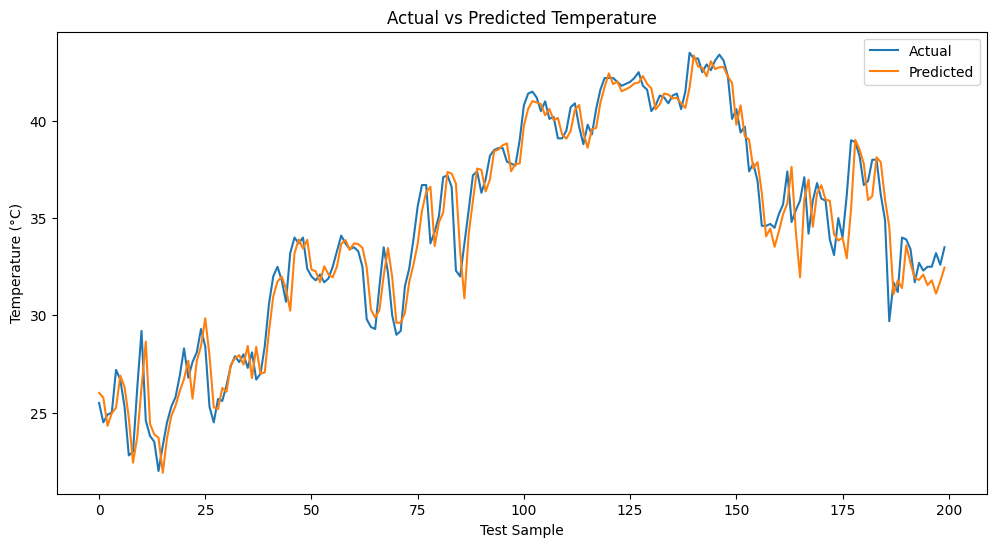

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    y_test_v3.values[:200],
    label="Actual"
)

plt.plot(
    y_pred_200[:200],
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature (°C)")
plt.title("Actual vs Predicted Temperature")
plt.legend()

plt.show()

In [80]:
mean_error = np.mean(
    y_test_v3.values - y_pred_200
)

print("Mean Error:", mean_error)

Mean Error: 0.10414507119386636


In [81]:
import joblib

In [82]:
joblib.dump(rf_200, "weather_temperature_model.pkl")

['weather_temperature_model.pkl']

In [83]:
model_info = {
    "model": rf_200,
    "features": features_v3
}

joblib.dump(model_info, "weather_temperature_model.pkl")

['weather_temperature_model.pkl']

In [84]:
loaded_model = joblib.load(
    "weather_temperature_model.pkl"
)

In [85]:
print(loaded_model["features"])

['temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'precipitation_sum', 'weather_code', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant', 'month', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_7', 'temp_rolling_3', 'temp_rolling_7']


In [86]:
loaded_rf = loaded_model["model"]

test_prediction = loaded_rf.predict(
    X_test_v3.iloc[:5]
)

print(test_prediction)

[26.0145 25.7755 24.321  24.9705 25.255 ]


In [87]:
print(test_prediction)

[26.0145 25.7755 24.321  24.9705 25.255 ]


In [88]:
import joblib
import pandas as pd

model_info = joblib.load("weather_temperature_model.pkl")

model = model_info["model"]
features = model_info["features"]

In [89]:
def predict_temperature(data):
    data = pd.DataFrame([data])

    prediction = model.predict(data[features])

    return prediction[0]

In [90]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Linear Regression + Lag",
        "Linear Regression + Lag + Rolling",
        "Random Forest - 100 Trees",
        "Random Forest - 200 Trees",
        "Random Forest - 200 Trees (No Today's Max)"
    ],
    "MAE": [
        0.940062,
        0.932717,
        0.931677,
        0.923719,
        0.920595,
        1.037858
    ],
    "RMSE": [
        1.311064,
        1.291678,
        1.290075,
        1.276305,
        1.272477,
        1.403501
    ],
    "R2": [
        0.925568,
        0.927753,
        0.927932,
        0.929462,
        0.929885,
        0.914702
    ]
})

print(results)

                                        Model       MAE      RMSE        R2
0                           Linear Regression  0.940062  1.311064  0.925568
1                     Linear Regression + Lag  0.932717  1.291678  0.927753
2           Linear Regression + Lag + Rolling  0.931677  1.290075  0.927932
3                   Random Forest - 100 Trees  0.923719  1.276305  0.929462
4                   Random Forest - 200 Trees  0.920595  1.272477  0.929885
5  Random Forest - 200 Trees (No Today's Max)  1.037858  1.403501  0.914702


In [91]:
import joblib

model_info = {
    "model": rf_200,
    "features": features_v3
}

joblib.dump(model_info, "weather_temperature_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [92]:
loaded = joblib.load("weather_temperature_model.pkl")

print(type(loaded["model"]))
print(loaded["features"])

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
['temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'precipitation_sum', 'weather_code', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant', 'month', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_7', 'temp_rolling_3', 'temp_rolling_7']


In [93]:
sample = X_test_v3.iloc[[0]]

prediction = rf_200.predict(sample)[0]

actual = y_test_v3.iloc[0]

print("Actual temperature:", actual)
print("Predicted temperature:", prediction)
print("Error:", actual - prediction)

Actual temperature: 25.5
Predicted temperature: 26.01450000000001
Error: -0.5145000000000088


In [94]:
def predict_from_row(row):
    """
    Predict tomorrow's maximum temperature
    using one prepared weather-data row.
    """

    row = row[features_v3].to_frame().T

    prediction = rf_200.predict(row)[0]

    return prediction

In [95]:
sample = X_test_v3.iloc[0]

prediction = predict_from_row(sample)

print(f"Predicted tomorrow's maximum temperature: {prediction:.2f}°C")

Predicted tomorrow's maximum temperature: 26.01°C


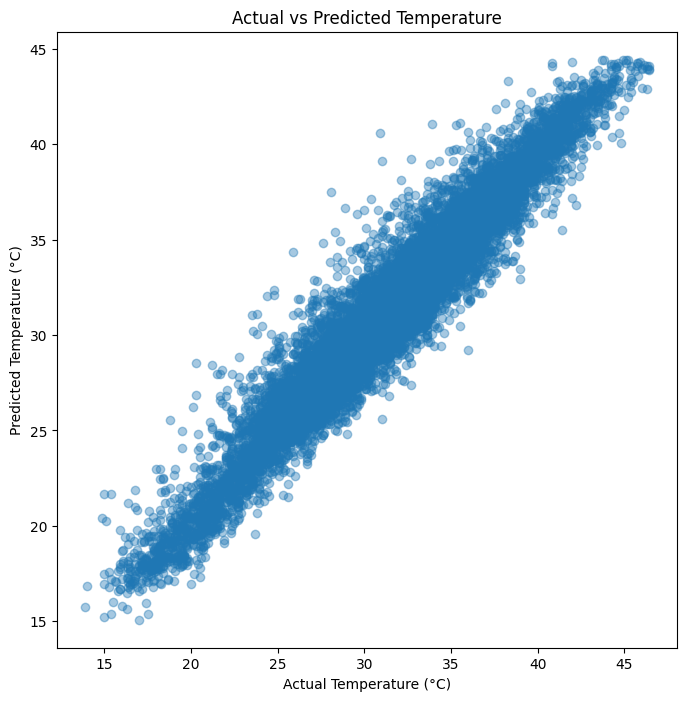

In [96]:
plt.figure(figsize=(8, 8))

plt.scatter(y_test_v3, y_pred_200, alpha=0.4)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature")

plt.show()

In [97]:
from google.colab import files

files.download("weather_temperature_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>